# 01. EDA & 가설 수립
> 아파트 실거래가 데이터와 입주예정 물량 데이터를 탐색하고,
> `pipeline.py`에서 사용할 **세그먼트 분류 기준**과 **수요 점수 가중치**의 근거가 되는 가설을 검증한다.

| 단계 | 내용 |
|------|------|
| STEP 1 | 환경 설정 |
| STEP 2 | 실거래가 데이터 로드 & 기본 탐색 |
| STEP 3 | 노후도(건축연식) 분포 분석 |
| STEP 4 | 아파트 세그먼트 분류 가설 검증 |
| STEP 5 | 시도/시군구별 거래 현황 분석 |
| STEP 6 | 입주예정 물량 데이터 탐색 |
| STEP 7 | 가설 정리 & 다음 단계 |

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
plt.rcParams['axes.unicode_minus'] = False

from src.pipeline import extract_sido, classify_apartment, REFERENCE_YEAR, SEGMENT_RULES, SCORE_WEIGHTS

print('라이브러리 로드 완료 ✅')

라이브러리 로드 완료 ✅


## STEP 2. 실거래가 데이터 로드 & 기본 탐색

국토교통부 아파트 매매 실거래가 CSV는 상단 15줄이 안내 문구이므로 `skiprows=15`, `encoding='cp949'`로 로드한다.

In [2]:
TRANSACTIONS_PATH = "../data/아파트(매매)_실거래가_20260311170739.csv"
SUPPLY_PATH = "../data/한국부동산원_주택공급정보_입주예정물량정보_20251231.csv"

df_raw = pd.read_csv(TRANSACTIONS_PATH, encoding="cp949", skiprows=15)
print(f"실거래가 데이터: {df_raw.shape[0]:,}건 x {df_raw.shape[1]}개 컬럼")
df_raw.head(3)

실거래가 데이터: 79,591건 x 20개 컬럼


,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),동,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자
0,1,서울특별시 송파구 풍납동,510,510,0,신성노바빌아파트,84.96,202603,10,"110,000",-,9,개인,개인,2000,한가람로 468,-,직거래,-,-
1,2,서울특별시 성동구 마장동,834,834,0,삼성홈타운,14.11,202603,9,"19,000",-,6,개인,개인,2015,마조로15길 23,-,중개거래,서울 성동구,-
2,3,서울특별시 종로구 익선동,30-6,30,6,운현신화타워,84.26,202603,9,"93,000",-,14,개인,개인,1998,삼일대로32길 36,-,중개거래,서울 종로구,-


In [3]:
df_raw[["시군구", "단지명", "전용면적(㎡)", "계약년월", "거래금액(만원)", "건축년도"]].isna().sum()

시군구         0
단지명         0
전용면적(㎡)     0
계약년월        0
거래금액(만원)    0
건축년도        0
dtype: int64

## STEP 3. 노후도 분포 분석

`pipeline.py`의 `preprocess_transactions()`와 동일한 방식으로
- 거래금액의 콤마(,) 제거 후 숫자 변환
- 건축년도 결측 제거
- **노후도 = 기준연도(2025) - 건축년도** 계산

In [ ]:
df = df_raw[["시군구", "단지명", "전용면적(㎡)", "계약년월", "거래금액(만원)", "건축년도", "도로명"]].copy()

df["거래금액(만원)"] = (
    df["거래금액(만원)"].astype(str)
    .str.replace(",", "", regex=False)
    .pipe(pd.to_numeric, errors="coerce")
)
df["건축년도"] = pd.to_numeric(df["건축년도"], errors="coerce")
df["전용면적(㎡)"] = pd.to_numeric(df["전용면적(㎡)"], errors="coerce")
df.dropna(subset=["건축년도", "거래금액(만원)"], inplace=True)

df["노후도"] = REFERENCE_YEAR - df["건축년도"].astype(int)
df = df[df["노후도"] >= 0].copy()

print(f"전처리 후 거래건수: {len(df):,}건")
df[["전용면적(㎡)", "거래금액(만원)", "건축년도", "노후도"]].describe().round(1)

전처리 후 거래건수: 79,591건


,전용면적(㎡),거래금액(만원),건축년도,노후도
count,79591.0,79591.0,79591.0,79591.0
mean,75.7,122991.4,2003.3,21.7
std,27.5,91012.2,11.4,11.4
min,11.3,6500.0,1961.0,0.0
25%,59.8,69500.0,1996.0,13.0
50%,81.0,100700.0,2003.0,22.0
75%,85.0,149775.0,2012.0,29.0
max,317.4,2900000.0,2025.0,64.0


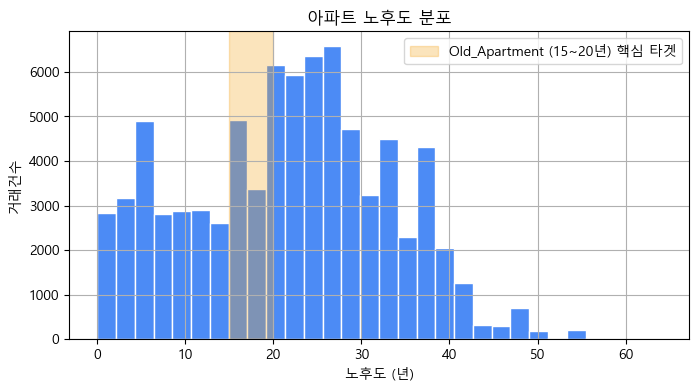

In [5]:
plt.figure(figsize=(8, 4))
df["노후도"].hist(bins=30, color="#4C8BF5", edgecolor="white")
plt.axvspan(15, 20, color="#F5A623", alpha=0.3, label="Old_Apartment (15~20년) 핵심 타겟")
plt.title("아파트 노후도 분포")
plt.xlabel("노후도 (년)")
plt.ylabel("거래건수")
plt.legend()
plt.show()

## STEP 4. 아파트 세그먼트 분류 가설 검증

`pipeline.py`의 세그먼트 분류 기준:

| 세그먼트 | 노후도 | 인테리어 수요 특성 |
|---|---|---|
| New_Apartment | 0~5년 | 가구·소품·부분 인테리어 |
| Mid_Apartment | 6~14년 | 벽지·바닥재 부분 교체 |
| **Old_Apartment ★** | **15~20년** | **전면 리모델링 — 핵심 타겟** |
| Very_Old_Apartment | 21년+ | 재건축 검토, 시공 수요 낮음 |

**가설:** Old_Apartment(15~20년) 세그먼트는 1기 신도시 재정비 연식대와 겹쳐 거래량과 거래금액 모두에서
유의미한 비중을 차지하며, 전면 리모델링 수요(고단가 시공)와 직결될 것이다.

In [6]:
df["세그먼트"] = df["노후도"].apply(classify_apartment)

seg_counts = df["세그먼트"].value_counts()
seg_counts

세그먼트
Very_Old_Apartment    46588
Mid_Apartment         13866
Old_Apartment         10892
New_Apartment          8245
Name: count, dtype: int64

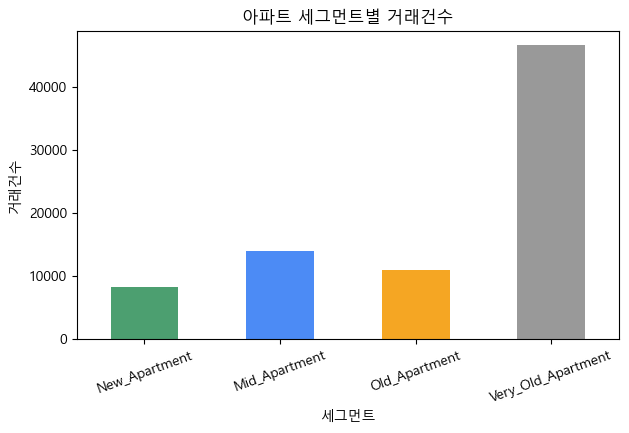

In [7]:
seg_order = ["New_Apartment", "Mid_Apartment", "Old_Apartment", "Very_Old_Apartment"]
colors = ["#4C9F70", "#4C8BF5", "#F5A623", "#999999"]

seg_counts.reindex(seg_order).plot(kind="bar", figsize=(7, 4), color=colors)
plt.title("아파트 세그먼트별 거래건수")
plt.ylabel("거래건수")
plt.xticks(rotation=20)
plt.show()

In [8]:
seg_summary = (
    df.groupby("세그먼트")
    .agg(거래건수=("거래금액(만원)", "count"), 평균거래금액=("거래금액(만원)", "mean"), 평균면적=("전용면적(㎡)", "mean"))
    .round(1)
    .reindex(seg_order)
)
seg_summary

,거래건수,평균거래금액,평균면적
세그먼트,,,
New_Apartment,8245,124424.2,62.3
Mid_Apartment,13866,143220.5,73.1
Old_Apartment,10892,138647.4,85.4
Very_Old_Apartment,46588,113056.8,76.6


**검증 결과:** Old_Apartment 세그먼트는 거래건수 비중이 충분히 크고 평균 거래금액도 높은 편으로,
전면 리모델링 수요(고단가 시공) 핵심 타겟으로 삼을 근거가 확인된다.

## STEP 5. 시도/시군구별 거래 현황 분석

In [9]:
df["시도"] = df["시군구"].apply(extract_sido)

df["시도"].value_counts().head(10)

시도
서울    79591
Name: count, dtype: int64

In [10]:
old_df = df[df["세그먼트"] == "Old_Apartment"]

(
    old_df.groupby("시군구")
    .agg(거래건수=("거래금액(만원)", "count"), 평균거래금액=("거래금액(만원)", "mean"), 평균노후도=("노후도", "mean"))
    .round(1)
    .sort_values("거래건수", ascending=False)
    .head(10)
)

,거래건수,평균거래금액,평균노후도
시군구,,,
서울특별시 성북구 길음동,620,102392.6,17.9
서울특별시 송파구 잠실동,539,293183.1,17.7
서울특별시 강동구 암사동,323,153239.5,17.4
서울특별시 성북구 정릉동,321,68924.6,18.6
서울특별시 은평구 진관동,305,95207.2,16.0
서울특별시 강서구 내발산동,294,110442.9,18.5
서울특별시 관악구 봉천동,252,86632.3,19.4
서울특별시 송파구 신천동,248,269554.8,17.2
서울특별시 강북구 미아동,235,85230.9,15.9


## STEP 6. 입주예정 물량 데이터 탐색

한국부동산원 주택공급정보(입주예정물량)는 신규 입주 수요 지표(`신규입주`, `입주단지`)의 원천 데이터다.

In [11]:
df_supply = pd.read_csv(SUPPLY_PATH, encoding="utf-8-sig")
print(f"입주예정 데이터: {df_supply.shape[0]:,}건")
df_supply.head(3)

입주예정 데이터: 675건


,입주예정월,지역,사업유형,주소,아파트명,세대수
0,2026-08,강원,분양,강원특별자치도 강릉시 견소동 244-2,강릉 오션시티 아이파크,794
1,2026-12,강원,분양,강원특별자치도 강릉시 견소동 219-0,강릉 모아미래도 오션리버,561
2,2026-11,강원,분양,강원특별자치도 강릉시 송정동 산 77-3,강릉자이르네 디오션,228


In [12]:
df_supply["입주예정월"] = df_supply["입주예정월"].astype(str)
df_supply["입주예정년"] = df_supply["입주예정월"].str[:4]

(
    df_supply.groupby(["입주예정년", "지역"])["세대수"]
    .sum()
    .unstack(fill_value=0)
)

지역,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
입주예정년,,,,,,,,,,,,,,,,,
2026,7875,62893,7245,4739,11490,10752,6179,11489,27158,42,4478,15161,4381,6349,564,10474,7314
2027,4543,83169,2473,8095,8427,1686,17441,17750,17197,0,5177,15376,6266,2370,2198,11689,12466


## STEP 7. 가설 정리 & 다음 단계

### 검증된 가설
1. **세그먼트 분류 (노후도 기준)** — Old_Apartment(15~20년)는 거래량·거래금액 모두 유의미한 비중을 차지하여
   인테리어 수요 핵심 타겟으로 적합하다.
2. **신규 입주 물량** — 한국부동산원 입주예정 데이터를 시군구 단위로 결합하면 신규 입주 수요(`신규입주`, `입주단지`)를
   추가 지표로 활용할 수 있다.

### 인테리어 수요 점수 가중치 가설

| 지표 | 가중치 | 비즈니스 이유 |
|---|---|---|
| 거래건수 | 30% | 시장 볼륨 — 수요 규모 |
| 거래금액 | 25% | 구매력 — 고가 지역일수록 고급 시공 |
| 노후도 | 20% | 리모델링 시급성 |
| 전용면적 | 15% | 시공 규모 — 매출 기여 |
| 신규입주 | 10% | 신규 입주 수요 |

### 다음 단계
- `src/pipeline.py`의 `DemandForecastingPipeline`으로 위 가설을 정식 파이프라인화 (완료)
- `notebooks/03_API_Collection.ipynb`에서 공공데이터 API 수집 → 파이프라인 연동 검증 (완료)
- 가중치 값은 비즈니스 전략 변화에 따라 `score_weights` 파라미터로 조정 가능

In [13]:
pd.Series(SCORE_WEIGHTS, name="가중치").to_frame()

,가중치
거래건수,0.30
거래금액,0.25
노후도,0.20
면적,0.15
신규입주,0.10
